In [20]:
data='https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
#!curl $data
#نجيب البيانات الرابط وانزلها هان 

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#استدعا مكتبة باندا

In [7]:
df=pd.read_csv('data.csv')
#قراة الملف 

In [8]:
df.head()
#طباعة اول خمس سطور

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [9]:
df.columns=df.columns.str.lower().str.replace(' ','_')
#الحين بدنا نعدل علي اسما الاعمدة اول اشي بنحفظ التعديل بعدين نجيب الاعمدة ونقوله النص احرف صغيرة وبعدين اي مسافة حط بدالها شرطة 

In [10]:
df.head()
#نرجع نطبع نشوف تعديلات 

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [11]:
df.dtypes
#هان نعمل كشف علي انواع البيانات 

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [12]:
df.dtypes[df.dtypes=='object']
# بندخل علي انواع البيانات وبتحديد بنطلع اعمدة النصوص 

make                 object
model                object
engine_fuel_type     object
transmission_type    object
driven_wheels        object
market_category      object
vehicle_size         object
vehicle_style        object
dtype: object

In [13]:
strings=list(df.dtypes[df.dtypes=='object'].index)
# هان نحفظهم في ليستا وبكونو مكونين من اندكس الي هو اسم العمود و فاليو الي هو اوبجكت الي هو نوع العمود بنختار انو لستا يكون فيها النصووص 

In [14]:
for col in strings:
    df[col]=df[col].str.lower().str.replace(' ','_')
    # هان بنعمل لوب الي بمر بليستا وياخذ منها عنصر عنصر وبعمل عليها العمليات المذكورة نصوص احرف صغيرة والمسافات شرطات 
# طريق مختصرة
df[strings]=df[strings].apply(lambda x:x.str.lower().str.replace(' ','_'))

In [15]:
df.head()
# نرجع نطبع نشوف التعديل 

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [23]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()
# قراة الاعمدة للوب خذ كل عمود لحاله وجيب اسما القوايم الخمسة كحد اقصي وجيب عدد القيم الفريدة يعني اسما القيم بدون تكرار

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

<Axes: xlabel='msrp', ylabel='Count'>

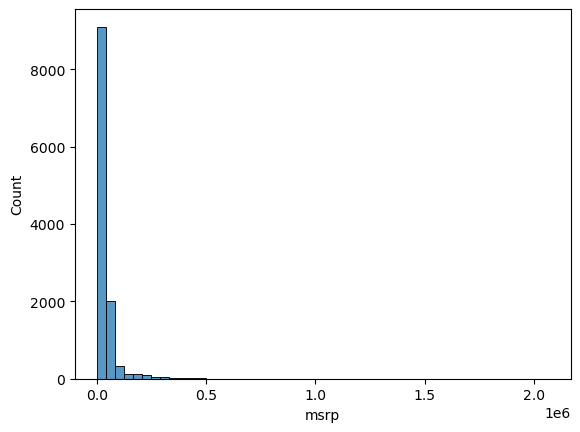

In [24]:
sns.histplot(df.msrp,bins=50)
# هان رسم بياني لفهم البيانات هو عدد السيارات وكم تترواح اسعارهم 
# هان بنواجه مشكلة الذيل الطويل الي مثال السيارات معظهم اسعارهم تترواح بين ١٠٠ الي ٢٠٠ الف فجاة نلاقي سيارات عددهم قليل لكن اسعارهم جدا كبيرة
#وهان القيم بتصير غير دقيقة مثلا لو بدي احسب المتوسط بجمع القيم وبينهم قيمة مشتتة  بتالي القيم المشتتة بتخلينا نغلط في حساب المتوسط 

<Axes: xlabel='msrp', ylabel='Count'>

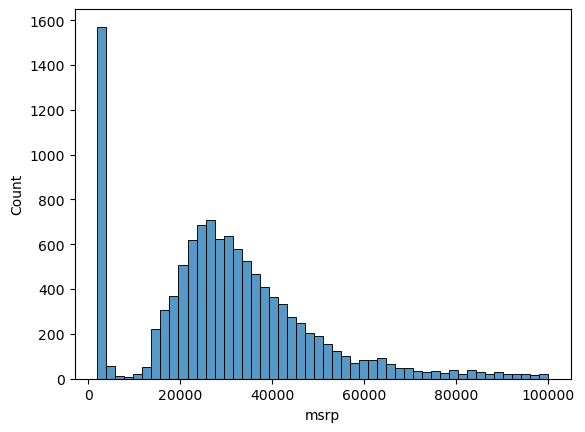

In [25]:
sns.histplot(df.msrp[df.msrp<100000],bins=50)
# لتوضيح ارسم العمدة البين يعني خمسين عمود عدد السيارات الي سعرها اقل من مليون 

<Axes: xlabel='msrp', ylabel='Count'>

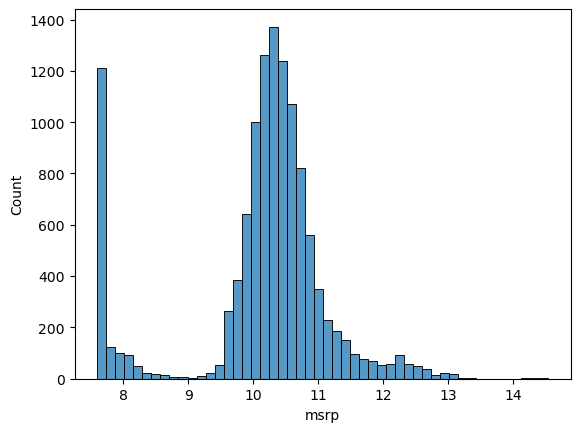

In [27]:
#np.log([0+1,1+1,10+1,1000+1])# نزود واحد عشان لو القيم صفر بيطلع ايرور وعشان نواتج تكون موجبة وصحيحة 
price_logs=np.log1p(df.msrp)
sns.histplot(price_logs,bins=50)
#هان حل مشكلة الذيل الطويل عن طريق اللوغاريتم الي بتخلي القيم متقاربة وبالاخص بتصغر القيم المرتفعة جدا ونمثلهم بنلاقي توزيع علي شكل جرس تقريبا توزيع طبيعي 
# الوغاريتم اكس زاد واحد يعني العنصر زاد واحد عشان لو في قيمة صفر بعمل ايرور

In [28]:
df.isnull().sum()
# هان معرفة عدد القيم المفقودة لتعامل معاها او حذفها او ملوها 

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [30]:
n=len(df)
# عدد الصفوف بلمف 
n_val=int(n*0.2)
# هان قيمة بيانات التحقق من عددهم الكامل عشرين بالمية 
n_test=int(n*0.2)
# هان نفس الاشي قيم الاختبار عشرين بالمية 
n_train=n-n_val-n_test
# هان قيم تدريب باقي الصفوف بعد اخذ اربعين بالمية من الاخبار وحقق 
print(f"n={n}")
print(f"n_test;{n_test} n_val;{n_val} n_train:{n_train}")
# ملحوظة ما خلينا تدريب ستين بالمية عشان ممكن يكون في كذا صف زيادة 

n=11914
n_test;2382 n_val;2382 n_train:7150


In [31]:
np.random.seed(2)
# هان بنثبت الارقام العشوائية 
idx=np.arange(n)
# بنعمل رانج بالارقام صفوف 
np.random.shuffle(idx)
# هان بنعمل الهم لخبطة 
print(idx[:10])
# عشان نحل المشكلة انو مثللا البيانات مترتب البي ام ورا بعض بتاخدهم بيانات الاختبار بينما بيانات التدريب تاخذ نوع بورش 

[ 2735  6720  5878 11190  4554  8001  2882   649   616  4459]


In [32]:
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]]
# هان نرجع ناخذ البيانات الملخبطة عن طريق الاندكس 
# الاول ناخذ من الاول الي عدد بيانات التدريب 
# التاني ناخذ من بيانات التدريب الي عدد بيانات تدريب زاد التحقق 
# وبالاخير من عدد بيانات تدريب وتحقق للباقي 

In [33]:
df_train=df_train.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
print(df_train.index[:5])
print(df_test.index[:5])
# الحين نواجه مشكلة الي هي الاندكس لما يقسم البيانات بحتفظ بالاندكس القديم وهاد لخبطة 
# بهادي العملية بنخلي الاندكس يبدا من صفر ونحذف الاندكس القديم 

RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=0, stop=5, step=1)


In [34]:
y_train=np.log1p(df_train.msrp.values)
y_test=np.log1p(df_test.msrp.values)
y_val=np.log1p(df_val.msrp.values)
print(y_train[:5])
# هان بنطلع اعمدة النتايج تبعت التدريب والاختبار وتحقق 
# وبنعملهم لوغاريتم عشان البيانات تصير محدودة ومافيها قيم شاذة 

[ 9.57574708  9.887663    9.89323518  7.60140233 10.93775686]


In [39]:
#del df_train['msrp']
#del df_val['msrp']
#del df_test['msrp']
df_train.head()
# هان ضروري من البيانات اكس نحذف عمود النتايج 

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


In [45]:
w=[0.01,0.04,0.002]
xi=[453,11,86]
w0=7.17
#هان يعني جبنا الميز 
# وي صفر تعني سعر مبديا بدون انحياز 
# الحين الوي هو تاثير كل ميزة 
def linear_regression(xi):
    n=len(xi)
    pred=w0 # السعر قبل اضافة التغيرات بحد الانحياز 
    for j in range(n):# نعمل لووب اخذ كل قيمة 
        pred=pred+w[j]*xi[j]# نحط تاثير حاصل الضرب الوزن في القيمة 
    return pred# يرجع النتايج 
print(linear_regression(xi))
# النتيجة هي عبارة عن السعر المبدئية للسيارة وبعدين بنجيب كل ميزة ونضربها بتاثيرها ونجمعهم ونتنبا بالاسعر 

12.312


In [42]:
np.expm1(12.312)
# السعر الي بطلع مش دقيق بسبب تم تحويله الي لوغاريتم نفك اللوغاريت عشان نعرف السعر 
# وفك اللوغاريتم يعني عكس العملية هي الاس ناقص واحد 

np.float64(222347.2221101062)

In [43]:
np.log1p(222347.2221101062)
# لتاكيد نحط نفسه في للوغاريتم وبرجعه الاصله 

np.float64(12.312)

In [46]:
w=np.array([0.01,0.04,0.002])
xi=np.array([453,11,86])
pred=w.dot(xi)+7.17
print(pred)
#الحين العملية هادي هي اختصار اللوب الي فوق الانه بحتاج وقت هان اختصاره نستخدم الضرب النقطي ونزود قيمة يو وبطلع الناتج

12.312000000000001


In [48]:
w_new=np.array([7.17,0.01,0.04,0.002])
xi_new=np.array([1,453,11,86])
pred=w_new.dot(xi_new)
print(pred)
# الحين الطريقة السحرية والعجبية لتدخيل يو الضرب النقطي واختصار اكبر قدر ممكن من الاكواد 
# انو ندخل يو مجموعة الاوزان بالمقابل الها في محموعة الميزات نحط واحد ما راح يكون اله اي ثاثير لكن هيك بنعمل ضرب نقطي شامل 

12.312


In [49]:
x1=[1,148,24,1385]
x2=[1,132,25,2031]
x3=[1,453,11,86]
X=np.array([x1,x2,x3])
w=np.array([7.17,0.01,0.04,0.002])
predictions=X.dot(w)
print(predictions)
#هان توقع السعر الاكتر من سيارة نفس الالية حطينا واحد للصفات ويو بليستا وضربناهم ضرب نقطي 

[12.38  13.552 12.312]


In [50]:
def linear(X):
    return X.dot(w)
pread=linear(X)
print(pread)
#هادي الصيغة النهاية للكود بدل للوب وقيم خارجية دخلنا القيم جوا وضربنا ضرب نقطي لكذا نوع سيارة بمنتهي سلاسة 

[12.38  13.552 12.312]


In [51]:
prices=np.expm1(pread)
print(prices)
# هان النحول السعر اللوغارتمي الي سعر عادي 

[237992.82334859 768348.51018973 222347.22211011]


In [131]:
def train_linear(X,y,r=0.001):
    ones=np.ones(X.shape[0])# نعمل عمود الواحد القيمة الوهمية نخلط يو دون انحياز علي المجموعة 
    X=np.column_stack([ones,X])# نضيفالعمود في مصفوفة المميزان اول عمود 
    XTX=X.T.dot(X)
    XTX=XTX+r*np.eye(XTX.shape[0])# هان بنعمل مصفوفة الوحدة بتكون ابعادها عدد صفوف اكس يعني بنضرب فيها معامل تنظيم وبعدين بنجمعها مع المتغي الاول 
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]# الحين بنحكيله رجع القيمة الاولي دون انحياز والقيم الاوزان الباقية 


In [132]:
#XTX.dot(XTX_inv).round(1)
#هان عشان نتاكد من معكوس المصفوفة يكون صح ضرب بعض بعطونا مصفوفة الواحدة 

In [133]:
X=np.array([
    [148,24,1385],
    [132,25,2031],
    [453,11,86],
    [158,24,185],
    [172,25,201],
    [413,11,86],
    [38,54,185],
    [142,25,431],
    [453,31,86]
])
y=[100,200,150,250,100,200,150,250,100]
w0,w=train_linear(X,y)
print("w0",w0)
print('w',w)
# النتاييج الاوزان  ونفصل الاوزن بدون انحياز عن الاوزان 

w0 321.4153161217777
w [-0.27484706 -3.02092163 -0.02536246]


In [134]:
# بنا نموذج بسيط جدا 
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
X_train=df_train[base].values
X_train
# اول حاجة الانحدار يطبق علي القيم الارقام فقط 
# هان بنعمل لستا بنضيف فيها مصفوفة الارقام 
#وبيانات التدريبي بنخليهم عبارة عن محتوي هدول الصفوف 

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [135]:
w0,w=train_linear(X_train,y_train)
print(w0,w)
# هان بدنا نتوقع الاوزان حيطلع كله نان السبب انو في قيم مفقودة بالمنتصف بتالي نواتج نان 

nan [nan nan nan nan nan]


In [136]:
df_train[base].isnull().sum()
# هان نعالج مشكلة القيم المفقودة عن طريق نجيب عدد القيم ومكانهم 

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [137]:
X_train=df_train[base].fillna(0).values
# هان عوضنا بالصفر 
#X_train=df_train[base].fillna(df_train[base].mean()).values
#هان عوضنا بالمتوسط بس انتبه المتوسط حساس للقيم الشاذة 
# الوسيط لا 


In [138]:
w0,w=train_linear(X_train,y_train)
print(w0,w)
# هان بنقله طلع الاوزان المتوقعة 

7.927203857232815 [ 9.70587807e-03 -1.59097868e-01  1.43800342e-02  1.49442174e-02
 -9.06844790e-06]


<Axes: ylabel='Count'>

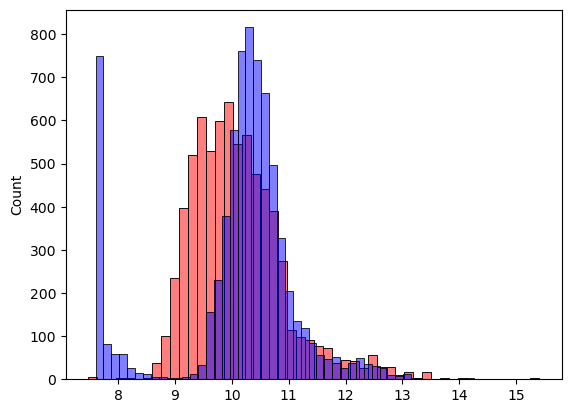

In [139]:
y_pred=w0+X_train.dot(w)
# الحين التوقع بكون يو الي بدون انحياز زاد الميزة ضرب وزنها
sns.histplot(y_pred,color='red',alpha=0.5,bins=50)
sns.histplot(y_train,color='blue',alpha=0.5,bins=50)

In [140]:
def rmse(y,y_p):
    mi=(y-y_p)**2
    mm=mi.mean()
    return np.sqrt(mm)
rmse(y_train,y_pred) 
#هادا الناتج بعني كم نسبة الخطا بالنموذج وبخلينا نمشي علي خطاه يعني لما نضيف خصائص جديدة ونعدل  بالتدريب والاعمدة بنشوف كم نسبة الخطا وهل انخفضت يعني النموذج قاعد يتحسن 

np.float64(0.7554192604313775)

In [141]:
def full(df):
    df_num=df[base]
    df_num=df_num.fillna(df_num.mean())
    X=df_num.values
    return X
# هان بنجهز البيانات  نحط البيانات الي في لستا القيم الارقام 
#وبعدين بنقولو حط بدل القيم المفقودة 

In [142]:
X_train=full(df_train)
w0,w=train_linear(X_train,y_train)
# هان الاول بيانات تدريب نعوض فيهم قيم نان 
#وبعدين ندرب النموذج عشان يطلع الاوزان 
# هان في سوال ليه ما خلينا بيانات التحقق هي الي اطلع الاوزان سبب انو بيانت التحقق هي بيانات المفروض نموذج ما يكون يعرف عنها اشي ولا يدرب عليها بالعكس تكون اول مرة يشوفها 

In [143]:
X_val=full(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)
# الحين هان بيانات التحقق تعويض القيم النان بالمتوسط 
# وهان بتم عملية التوقع نتاج النموذج  من خلال الاوزان الي طلعت من مرحلة تدريب 
# وبالاخير تنشوف نسبة جذر المتوسط التربيعي للخطا 
# يعني نعرف هل النموذج ادرب كويس علي بيانات التدريب ولا 
# يعني لو نسبة الخطا في تدريب نفس نسبة الخطا في التحقق يعني نموذج اتعلم كويس 
# لكن لو النتايج نموذج بالتدريب اعلي بكتير من تحقيق هادا يعني النموذج زيادة تعلم يعني حفظ نتايج التدريب ما اتعلم منها 
# لكن لو بالتحقيق اقل من تدريب يعني النموذج ما اتعلم اصلا من البيانات 

np.float64(0.7502497915128764)

In [144]:
makes= list(df.make.value_counts().head().index)# هادا يعني بحط البيانات نوع السيارة بجيب اكتر خمسة انواع متكررة وبجيب اسماهم وبحطهم بليستا 
# ليه بنحطها برا عشان مش كل مرة يتم استدعا الدالة حتعمل قيم جديدة 
categroical_variables=['engine_fuel_type','transmission_type','driven_wheels','market_category','vehicle_size','vehicle_style']
# هان عملنا قائمة بكل الاعمدة الفئوية عشان نحولها الاعمدة جديدة تحتوي علي ارقام وتكون مصنفة حسب الفئات 
categories={}
# عملنا قاموس فارغ 
for c in categroical_variables:
    categories[c]=list(df_train[c].value_counts().head().index)
# هان بنعمل للوب لكل القائمة الموجودة 
# بناخذ عنصر عنصر من القائمة وبنحفظه بالديكشنري وبنعمله ليستا تحتوي علي اكتر خمس قيم مكررة 
#الناتج بكون عبارة عن قاموس بحتوي علي مفتاح اسمة الميزة ومحتوي الي هو عبارة عن العمود الجديد تبع الفئة 

In [145]:
def full(df):
    df.copy()# هان عملنا نسخة من الملف عشان اي تعديل ما يتم علي الاصلية 
    feutures=base.copy() # نعمل نسخة من مصفوفة الارقام تبعت تدريب النموذح 
    df['age']=2017-df.year# هان عملنا عمود جديد اسمه العمر وحطينا فيه اعلي قيمة ناقص سنة الصناعة 
    #feutures=base+['age']# وبعدين العمو الي عملنه ضفته في الميزات الارقام
    feutures.append('age')
    for v in [2,3,4]:
        df[f'num_doors_{v}']=(df.number_of_doors==v).astype(int)
        # هان بنعمل اعمدة جديدة تحتوي علي ميزات جديدة من فئات الي توي حولنهم الي ارقام وبنشوف اذا بمثل الفئة بنحط واححد اذا لا صفر 
        feutures.append(f'num_doors_{v}')
    for v in makes:
        df[f'make_{v}']=(df.make==v).astype(int)
        feutures.append(f'make_{v}')
    for c,values in categories.items(): # لكل سي المفتاح وفاليو المحتوي 
        for v in values:# لكل قيمة 
            df[f'{c}_{v}']=(df[c]==v).astype(int)# انشا عمود جديد اذا كانت السيار من الفئة ثرو والاتجر يحولها الواحد  اسم المفتاح و المحتوي 
            feutures.append(f'{c}_{v}')# اضافة العمود للقائمة 
    df_num=df[feutures] 
    df_num=df_num.fillna(df_num.mean())
    X=df_num.values
    return X
# كدا بنكون عملنا عمود جديد علي ملف بيانات كوبي مش الاصلي 

In [150]:
X_train=full(df_train)
w0,w=train_linear(X_train,y_train,r=0.01)
# هان عدلنا بيانات التدريب ضفنا فيها عمود العمر والقيم نان ملناها وبعدين دربنا النموذج يجيب الاوزان 

In [151]:
X_val=full(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)
#print(type(y_pred))
# هان بدنا نتحقق من بيانات التحقق وبعدين دربنا النموذج  يتوقع نتايج للبيانات اول مرة اشوفهم 
# بعدين نحسب الخطا ونشوف اذا زي ما هو يعني العمود ماله فايدة واذا نسبة الخطا اكبر يعني العمود كان اله تاثير عكسي علي البيانات وخرب النموذج
# واذا قل يعني العمود حسن النموذج ودليل نسبة الخطا انخفضت 
# تعديل بعد اضافة المتغيرات الفئوية الي هو بنجيب ميزات النصوص وانحولهم الي ارقام واحد او صفر يعني العمود بنحوله الي كذا عمود كل واحد يتبع فئة معينة 
# المهم نكتشف بعد اضافة كمية كبيرة جدا من الاعمدة الجديدة انو نسبة الخطا ارتفعت بطريقة جدا جدا كبيرة 
# بسبب انو المصفوفة بطلت قادرة تجيب الانعاكسات وفيس قيم مكررة وفي قيمة شاذا 

np.float64(0.45482399244341004)

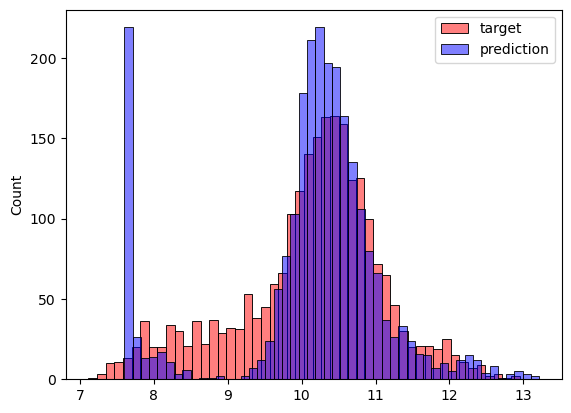

In [148]:
sns.histplot(y_pred,label='target',color='red',alpha=0.5,bins=50)
sns.histplot(y_val,label='prediction',color='blue',alpha=0.5,bins=50)
plt.legend()
# الحين رسم البياني عشان نشوف توزيع البيانات للعمود النتايج وعمود التوقع 
# وبنشوف انو في تحسن وتتطابق ولكن لسا في اختلاف 

In [105]:
for v in [2,3,4]:
    df[f'num_doors_{v}']=(df.number_of_doors==v).astype(int)
    #    features.append(f'num_door_{v}')
# الحين هان هو مثال الابواب حركة للوب لكل عدد ابوب 
# هان بنعمل متغيز لكل فئة ابواب وبعدين بنقوله شوف اذا في ميزة الابواب بساوي مثلا اتنين يعمني عندها بابين حط واحد عند عمود البابين واحفظ النتايج بنوع الارقام
#وبعدين بنحط اعمدة الفئات الي الميزات الارقام 

In [130]:
#makes= list(df.make.value_counts().head().index)
# هان بنقول جيب القيم الاكتر شيوعا لنوع السيارات  اكتر خمس قيم جيب الاسما وحطهم بليستا 
#for v in makes:
#    df[f'make_{v}']=(df.make==v).astype(int)# هان بنعمل متغير فئة سيارة ونشوف اذا نوع السيارة بساوي الفئة بنحط النتاج في ارقام 
#    features.append(f'make_{v}')

In [152]:
# تجربة اكتر من قيمة مختلفةج للمعامل واختيار الافضل 
for r in[0.0,0.0001,0.001,0.01,0.1,1.0,10]:
    X_train=full(df_train)
    w0,w=train_linear(X_train,y_train,r=r)
    X_val=full(df_val)
    y_pred=w0+X_val.dot(w)
    score=rmse(y_val,y_pred)
    print(f'r{r:.4f}, RMSE={score:.4f}')

r0.0000, RMSE=53.8015
r0.0001, RMSE=0.4548
r0.0010, RMSE=0.4548
r0.0100, RMSE=0.4548
r0.1000, RMSE=0.4549
r1.0000, RMSE=0.4555
r10.0000, RMSE=0.4669


In [154]:
df_full_train=pd.concat([df_train,df_val]).reset_index(drop=True)
#هان بدنا نجمع نربط بيانات التدريب مع التحقق وكمان نحذف الاندكس القديم ونعمل اندكس جديد
X_full_train=full(df_full_train)
# وبعدين بنعملهم في دالة تحضير البيانات 
y_full_train=np.concatenate([y_train,y_val])
# بعدينن نربط النتايج ببعض 
w0,w=train_linear(X_full_train,y_full_train,r=0.001)
# هان طلع الاوزان تبعت النواتج 

In [156]:
X_test=full(df_test)
# نعمل تحضير بيانات البيانات الاختبار 
y_pred=w0+X_test.dot(w)
# وهان نجيب التوقع النتيجة 
score=rmse(y_test,y_pred)
# وهان نقيم نسبة الخطا 
print(score)

0.4511109608977998


In [157]:
car=df_test.iloc[20].to_dict()
# نهمل اختبار علي سيارة واحدة ونشوف الوضع ونحطه بقاموس عشان نعرف نتعامل معاه 
df_small=pd.DataFrame([car])# انشا صف واحد 
# هان بنحطه بسلسة عشان التوقع ما بقبل غر سلسلة 

X_small=full(df_small)
# هان بنطبق دالة تجهيز البيانات 

In [159]:
y_pred=w0+X_small.dot(w)
# هان بندرب النموذج 
#y_pred=y_pred[0]
print(y_pred)

[10.45934955]


In [160]:
np.expm1(y_pred)
# والسعر بكون للوغاريتم نفكها 

array([34867.86355203])

In [161]:
np.expm1(y_test[20])
# ونستدعي السعر الاصلي عشان نشوف الفرق 

np.float64(35000.00000000001)